# Simulación DES de un sistema Reverse Proxy

En este notebook se presentan los primeros resultados obtenidos para el simulador de eventos discretos del sistema reverse proxy. El objetivo principal es analizar cómo se comporta el sistema frente a distintas cargas de entrada y distintas capacidades máximas de atención.

El reverse proxy se modela como un sistema con capacidad finita. Cada solicitud que llega puede ser aceptada si existe capacidad disponible o rechazada si el proxy se encuentra completamente ocupado. A partir de esta lógica se obtienen métricas como la probabilidad de bloqueo, la utilización promedio del sistema y la cantidad de solicitudes aceptadas o rechazadas.

El notebook se organiza en tres partes principales:

1. Validación del simulador usando Erlang B.
2. Comparación de escenarios de carga.
3. Barrido de capacidad del reverse proxy.

In [13]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Detectar raíz del proyecto.
# Si el notebook se ejecuta desde /notebooks, subimos un nivel.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RESULTS = ROOT / "results"

print("Directorio raíz:", ROOT)
print("Directorio de resultados:", RESULTS)
print("Existe carpeta results:", RESULTS.exists())

Directorio raíz: C:\Users\edopa\OneDrive\Desktop\rproxy-sim
Directorio de resultados: C:\Users\edopa\OneDrive\Desktop\rproxy-sim\results
Existe carpeta results: True


## 1. Modelo base del simulador

El primer modelo implementado representa al reverse proxy como un sistema de pérdida M/M/c/c. Esto significa que las llegadas de solicitudes se modelan mediante una distribución exponencial, los tiempos de servicio también se modelan de forma exponencial y existe una capacidad máxima finita de solicitudes simultáneas.

En esta versión inicial no se considera una cola de espera. Por lo tanto, si una solicitud llega cuando todos los recursos del proxy están ocupados, esta se rechaza inmediatamente.

Los elementos principales del modelo DES son:

- **Estado del sistema:** reloj de simulación y cantidad de solicitudes en servicio.
- **Entidades:** solicitudes que llegan al reverse proxy.
- **Eventos:** llegada de una solicitud y salida de una solicitud.
- **FEL:** lista de eventos futuros ordenada cronológicamente.
- **Condición de término:** tiempo máximo de simulación.
- **Métricas:** solicitudes aceptadas, rechazadas, completadas, probabilidad de bloqueo, utilización promedio y ocupación máxima.

Este modelo base es simple, pero permite estudiar directamente la saturación del reverse proxy y sirve como punto de partida para escenarios más complejos.

## 2. Validación puntual contra Erlang B

Antes de utilizar el simulador en escenarios más complejos, se realizó una primera validación contra un resultado teórico conocido. Para esto se comparó la probabilidad de bloqueo simulada con la fórmula de Erlang B, considerando un sistema M/M/c/c.

Esta validación permite revisar si el núcleo del simulador reproduce correctamente el comportamiento esperado de un sistema de pérdida con capacidad finita y sin cola.


Validacion Erlang B - Simulador DES minimo

Parametros:
arrival_rate = 8.0
service_rate = 1.0
capacity = 10
simulation_time = 1000
replicas = 30

Resultados:
bloqueo_promedio_simulado = 0.12140635415015041
desviacion_estandar = 0.006189497411669924
intervalo_confianza_95 = [0.11919147094684933, 0.1236212373534515]
erlang_b_teorico = 0.1216610642529515
error_relativo = 0.0020936040989376187

Archivos generados:
C:\Users\edopa\OneDrive\Desktop\rproxy-sim\results\validation_erlang_b_replicas.csv
C:\Users\edopa\OneDrive\Desktop\rproxy-sim\results\validation_erlang_b_plot.png



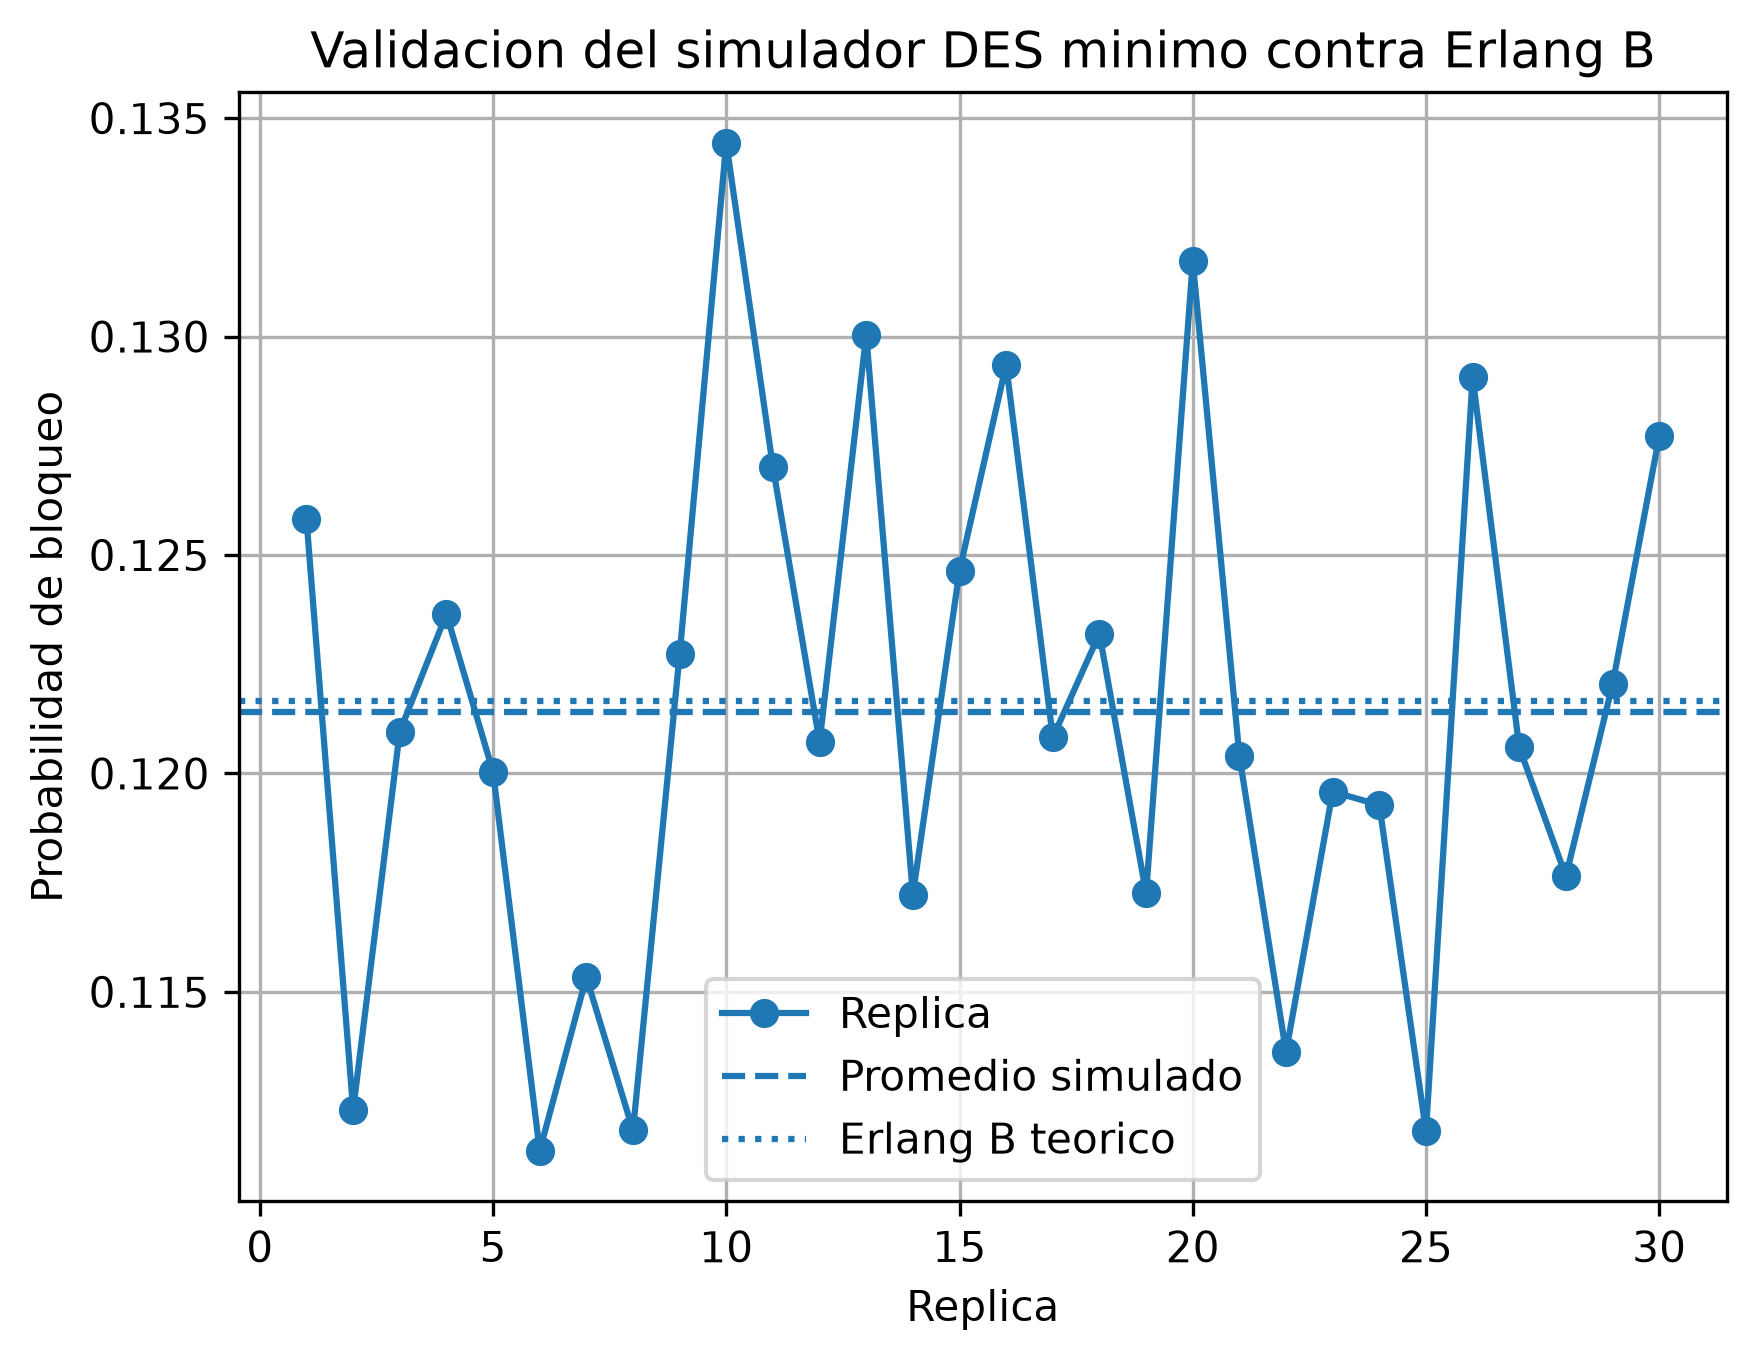

In [14]:
validation_summary_path = RESULTS / "validation_erlang_b_summary.txt"
validation_plot_path = RESULTS / "validation_erlang_b_plot.png"

print(validation_summary_path.read_text(encoding="utf-8"))

display(Image(filename=str(validation_plot_path)))

### Interpretación del gráfico de validación

En el gráfico se observa la probabilidad de bloqueo obtenida en cada una de las 30 réplicas de simulación. Como es esperable en un modelo probabilístico, los valores no son exactamente iguales entre réplicas, pero se mantienen alrededor de un rango bastante acotado.

La línea segmentada representa el promedio obtenido mediante simulación, mientras que la línea punteada representa el valor teórico calculado con Erlang B. Ambas líneas quedan prácticamente superpuestas, lo que indica que el simulador está reproduciendo correctamente el comportamiento esperado para un sistema M/M/c/c.

Este resultado es importante porque permite validar el núcleo inicial del simulador antes de usarlo en escenarios más complejos. En otras palabras, antes de comparar distintas cargas o capacidades del reverse proxy, se verificó que el modelo base entrega resultados consistentes con una fórmula teórica conocida.


**Resultado clave de validación:**  
El bloqueo promedio simulado fue aproximadamente 0.1214, mientras que Erlang B entregó 0.1217. El error relativo fue cercano a 0.21%, por lo que la diferencia entre simulación y teoría es muy baja.

## 3. Validación extendida: barrido de carga contra Erlang B

Además de validar el simulador en un caso puntual, se realizó un barrido de carga para comparar el comportamiento del modelo frente a distintos niveles de demanda. En este experimento se mantuvo fija la capacidad del reverse proxy y se variaron las tasas de llegada de solicitudes.

Los parámetros utilizados fueron:

* Tasa de servicio: μ = 1.0
* Capacidad del reverse proxy: c = 10
* Tiempo de simulación: 1000 unidades de tiempo
* Número de réplicas: 30
* Tasas de llegada evaluadas: λ = 2, 4, 6, 8, 10, 12, 14 y 16

El objetivo de este experimento fue comparar, para cada valor de λ, la probabilidad de bloqueo promedio obtenida mediante simulación con la probabilidad teórica calculada mediante Erlang B.

Los resultados muestran que el simulador sigue de forma muy cercana la tendencia teórica. A medida que aumenta la tasa de llegada, la probabilidad de bloqueo también crece, lo cual es consistente con el comportamiento esperado de un sistema con capacidad finita. Si llegan más solicitudes y la capacidad se mantiene constante, aumenta la probabilidad de que el reverse proxy se encuentre ocupado y rechace nuevas solicitudes.

Para cargas intermedias, la coincidencia entre simulación y teoría es especialmente clara. Por ejemplo, para λ = 6, el bloqueo simulado fue cercano a 4.31%, prácticamente igual al valor teórico. Para λ = 8, el bloqueo simulado fue aproximadamente 12.06%, mientras que Erlang B entregó cerca de 12.17%. Para λ = 10, el valor simulado fue cercano a 21.62%, muy próximo al valor teórico de 21.46%.

En cargas más altas también se mantiene la cercanía entre ambos resultados. Para λ = 16, la simulación entregó una probabilidad de bloqueo aproximada de 43.86%, mientras que Erlang B entregó cerca de 44.06%.

El caso λ = 2 presenta un error relativo más alto, pero esto se debe a que la probabilidad de bloqueo teórica es muy pequeña. En términos absolutos, la diferencia sigue siendo mínima, por lo que no afecta la interpretación general del experimento.

En general, este barrido de carga refuerza la validación del simulador, ya que muestra que no solo coincide con Erlang B en un punto específico, sino que también reproduce correctamente la curva de aumento del bloqueo al incrementar la carga ofrecida.


In [20]:
load_sweep_df = pd.read_csv(RESULTS / "load_sweep_erlang_b_summary.csv")

load_sweep_table = load_sweep_df[
    [
        "arrival_rate",
        "service_rate",
        "capacity",
        "blocking_probability_mean",
        "erlang_b_theoretical",
        "relative_error",
        "mean_rejected",
        "mean_accepted",
        "mean_arrivals",
    ]
].copy()

load_sweep_table["blocking_probability_mean_%"] = 100 * load_sweep_table["blocking_probability_mean"]
load_sweep_table["erlang_b_theoretical_%"] = 100 * load_sweep_table["erlang_b_theoretical"]

load_sweep_table[
    [
        "arrival_rate",
        "capacity",
        "blocking_probability_mean_%",
        "erlang_b_theoretical_%",
        "relative_error",
        "mean_rejected",
        "mean_accepted",
        "mean_arrivals",
    ]
]

,arrival_rate,capacity,blocking_probability_mean_%,erlang_b_theoretical_%,relative_error,mean_rejected,mean_accepted,mean_arrivals
0,2,10,0.004929,0.003819,0.290751,0.100000,1996.166667,1996.266667
1,4,10,0.545500,0.530755,0.027781,21.800000,3966.500000,3988.300000
2,6,10,4.305122,4.314184,0.002100,258.033333,5732.400000,5990.433333
3,8,10,12.060498,12.166106,0.008681,963.566667,7022.666667,7986.233333
4,10,10,21.620170,21.458234,0.007547,2164.000000,7843.266667,10007.266667
5,12,10,30.351215,30.192504,0.005257,3647.233333,8367.700000,12014.933333
6,14,10,37.642277,37.728475,0.002285,5273.300000,8733.933333,14007.233333
7,16,10,43.860909,44.056144,0.004431,7010.633333,8972.266667,15982.900000


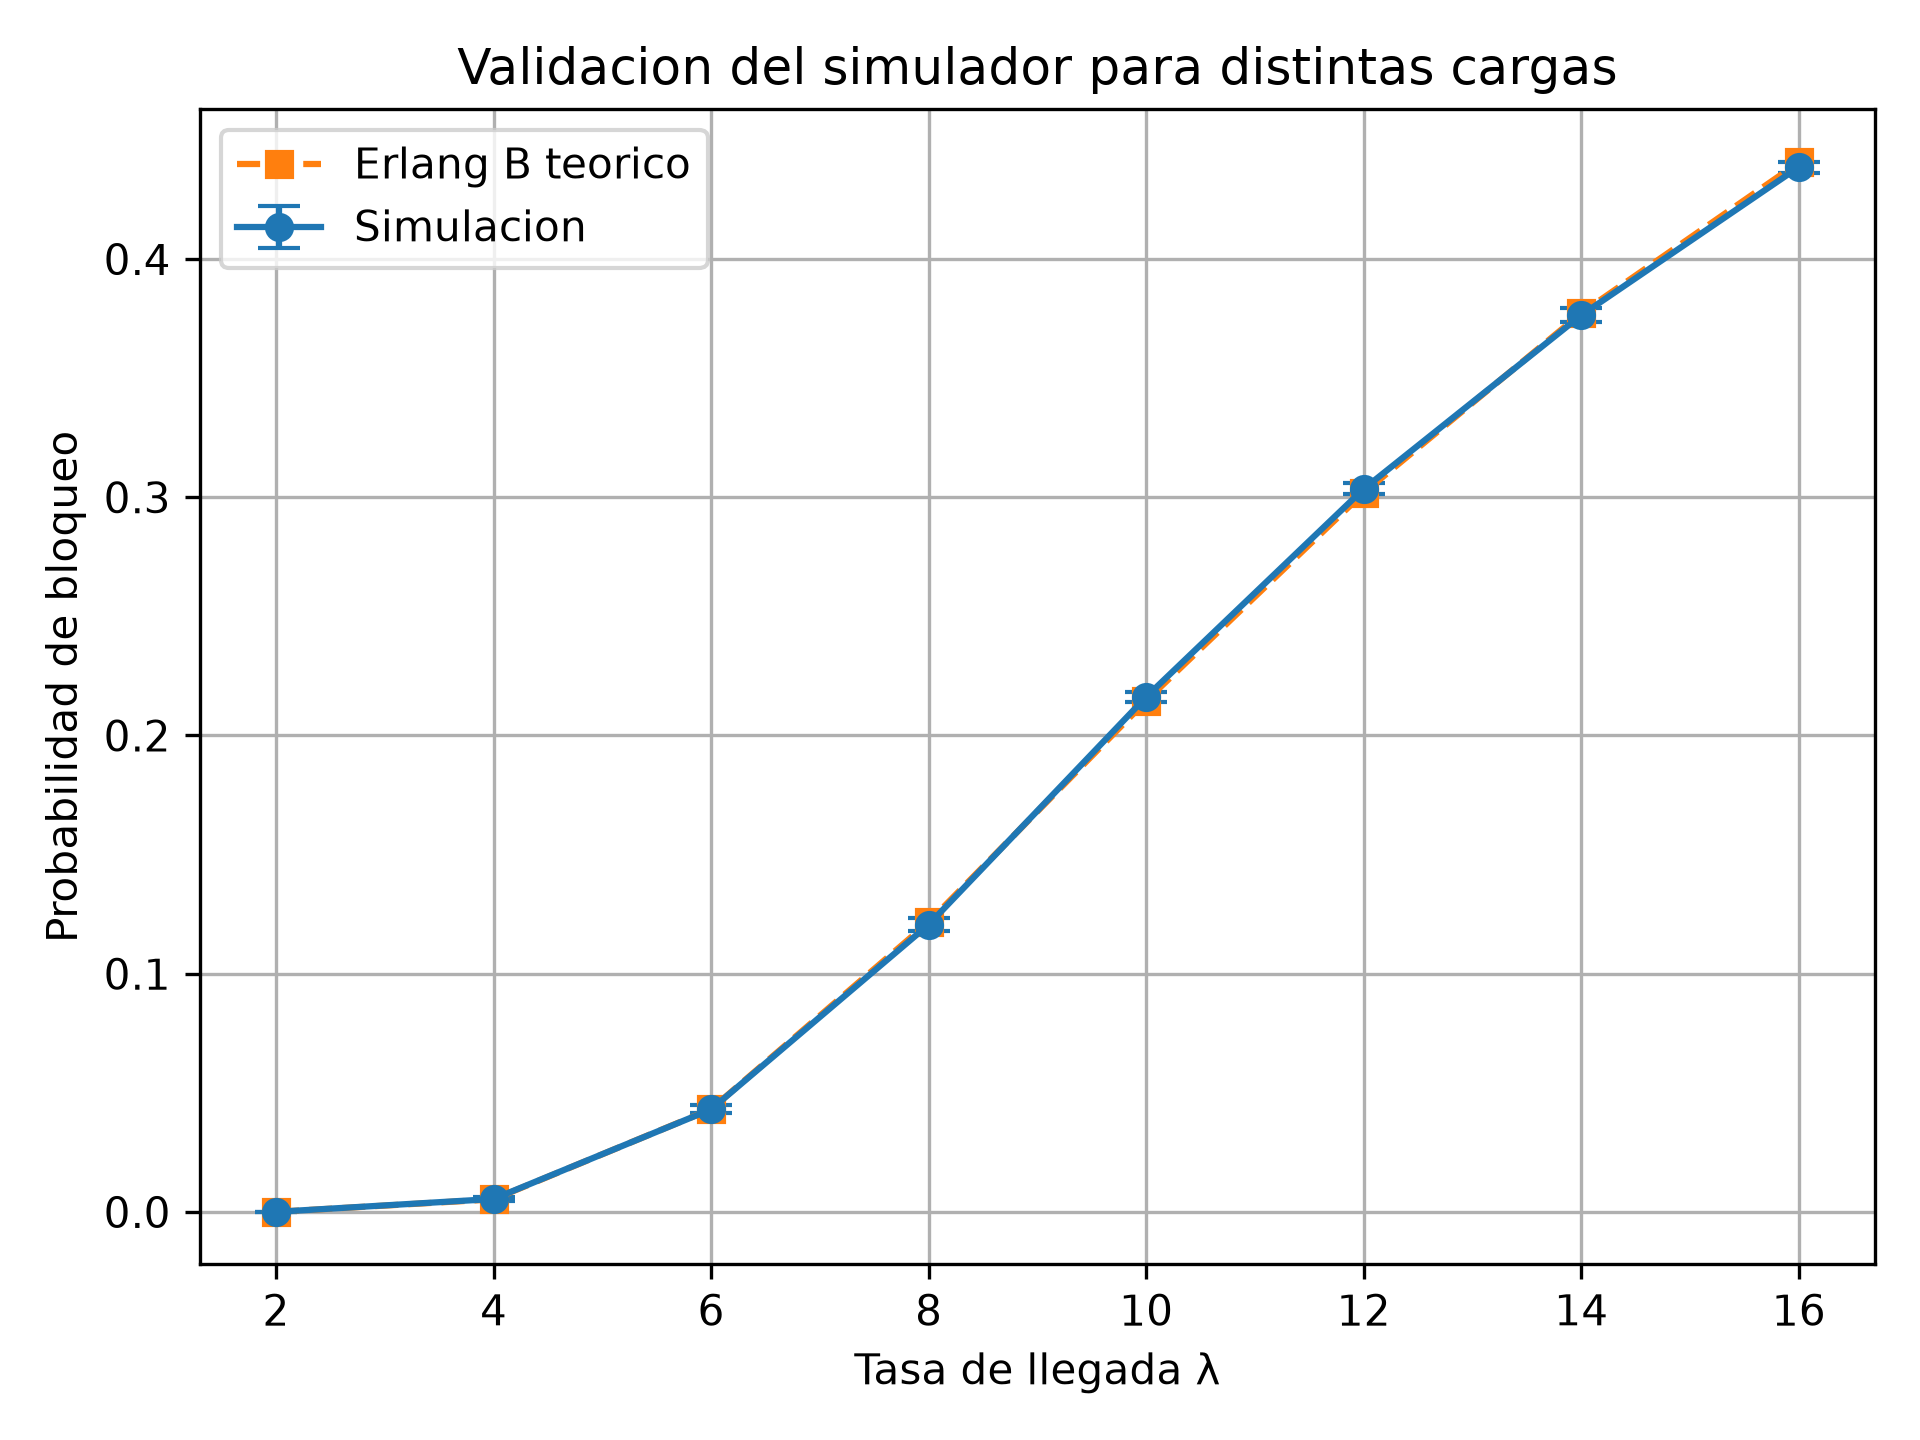

In [21]:
display(Image(filename=str(RESULTS / "load_sweep_erlang_b_plot.png")))

## 4. Comparación de escenarios de carga

Luego de validar el comportamiento del simulador, se evaluaron distintos escenarios de carga. En esta parte se mantuvo fija la cantidad de usuarios activos y la capacidad del reverse proxy, variando la intensidad de tráfico mediante la tasa de solicitudes por usuario y un factor de ráfaga.

El objetivo es observar cómo cambia la probabilidad de bloqueo cuando la demanda aumenta bajo distintas condiciones de uso.

In [22]:
scenario_df = pd.read_csv(RESULTS / "scenario_comparison_summary.csv")

scenario_table = scenario_df[
    [
        "scenario",
        "arrival_rate",
        "active_users",
        "burst_factor",
        "blocking_probability_mean",
        "utilization_mean",
        "mean_rejected",
        "mean_accepted",
        "mean_arrivals",
    ]
].copy()

scenario_table["blocking_probability_mean_%"] = 100 * scenario_table["blocking_probability_mean"]
scenario_table["utilization_mean_%"] = 100 * scenario_table["utilization_mean"]

scenario_table[
    [
        "scenario",
        "arrival_rate",
        "active_users",
        "burst_factor",
        "blocking_probability_mean_%",
        "utilization_mean_%",
        "mean_rejected",
        "mean_accepted",
        "mean_arrivals",
    ]
]

,scenario,arrival_rate,active_users,burst_factor,blocking_probability_mean_%,utilization_mean_%,mean_rejected,mean_accepted,mean_arrivals
0,residencial_baja_carga,5.000,5000,1.00,1.839207,48.937416,91.700000,4890.600000,4982.300000
1,mixta_residencial_comercial,7.200,5000,1.20,8.679965,65.652304,624.466667,6565.200000,7189.666667
2,campus_universitario,8.775,5000,1.35,15.838773,73.921619,1390.566667,7387.133333,8777.700000
3,corredor_metro_comercial,11.250,5000,1.50,26.980689,82.015393,3036.066667,8215.200000,11251.266667
4,evento_peak,15.300,5000,1.80,42.046451,88.688075,6439.566667,8875.066667,15314.633333


### Interpretación de la comparación de escenarios

La tabla resume el comportamiento del reverse proxy para cinco escenarios de carga distintos, manteniendo fija la cantidad de usuarios activos en 5000 y la capacidad del proxy en 10 solicitudes simultáneas.

Se observa que, a medida que aumenta la tasa efectiva de llegada, también aumenta la probabilidad de bloqueo. En el escenario `residencial_baja_carga`, el bloqueo promedio es bajo, cercano al 1.84%, lo que indica que el sistema todavía tiene margen para atender la mayoría de las solicitudes.

En cambio, en escenarios con mayor concentración de tráfico, el rechazo aumenta de forma importante. Para `campus_universitario`, el bloqueo promedio llega a 15.84%, mientras que para `corredor_metro_comercial` alcanza aproximadamente 26.98%. Esto muestra que una capacidad de 10 solicitudes simultáneas ya no es suficiente para cargas más intensas.

El caso más crítico es `evento_peak`, donde la probabilidad de bloqueo supera el 42%. Este escenario representa una situación de alta demanda temporal, por lo que el resultado indica que el reverse proxy se satura con facilidad si no se aumenta su capacidad.

En general, esta comparación permite ver que el sistema responde bien en escenarios de baja carga, pero comienza a degradarse cuando la demanda se concentra. Esto justifica realizar un segundo análisis variando la capacidad del proxy para estimar cuántos recursos serían necesarios para reducir el rechazo.


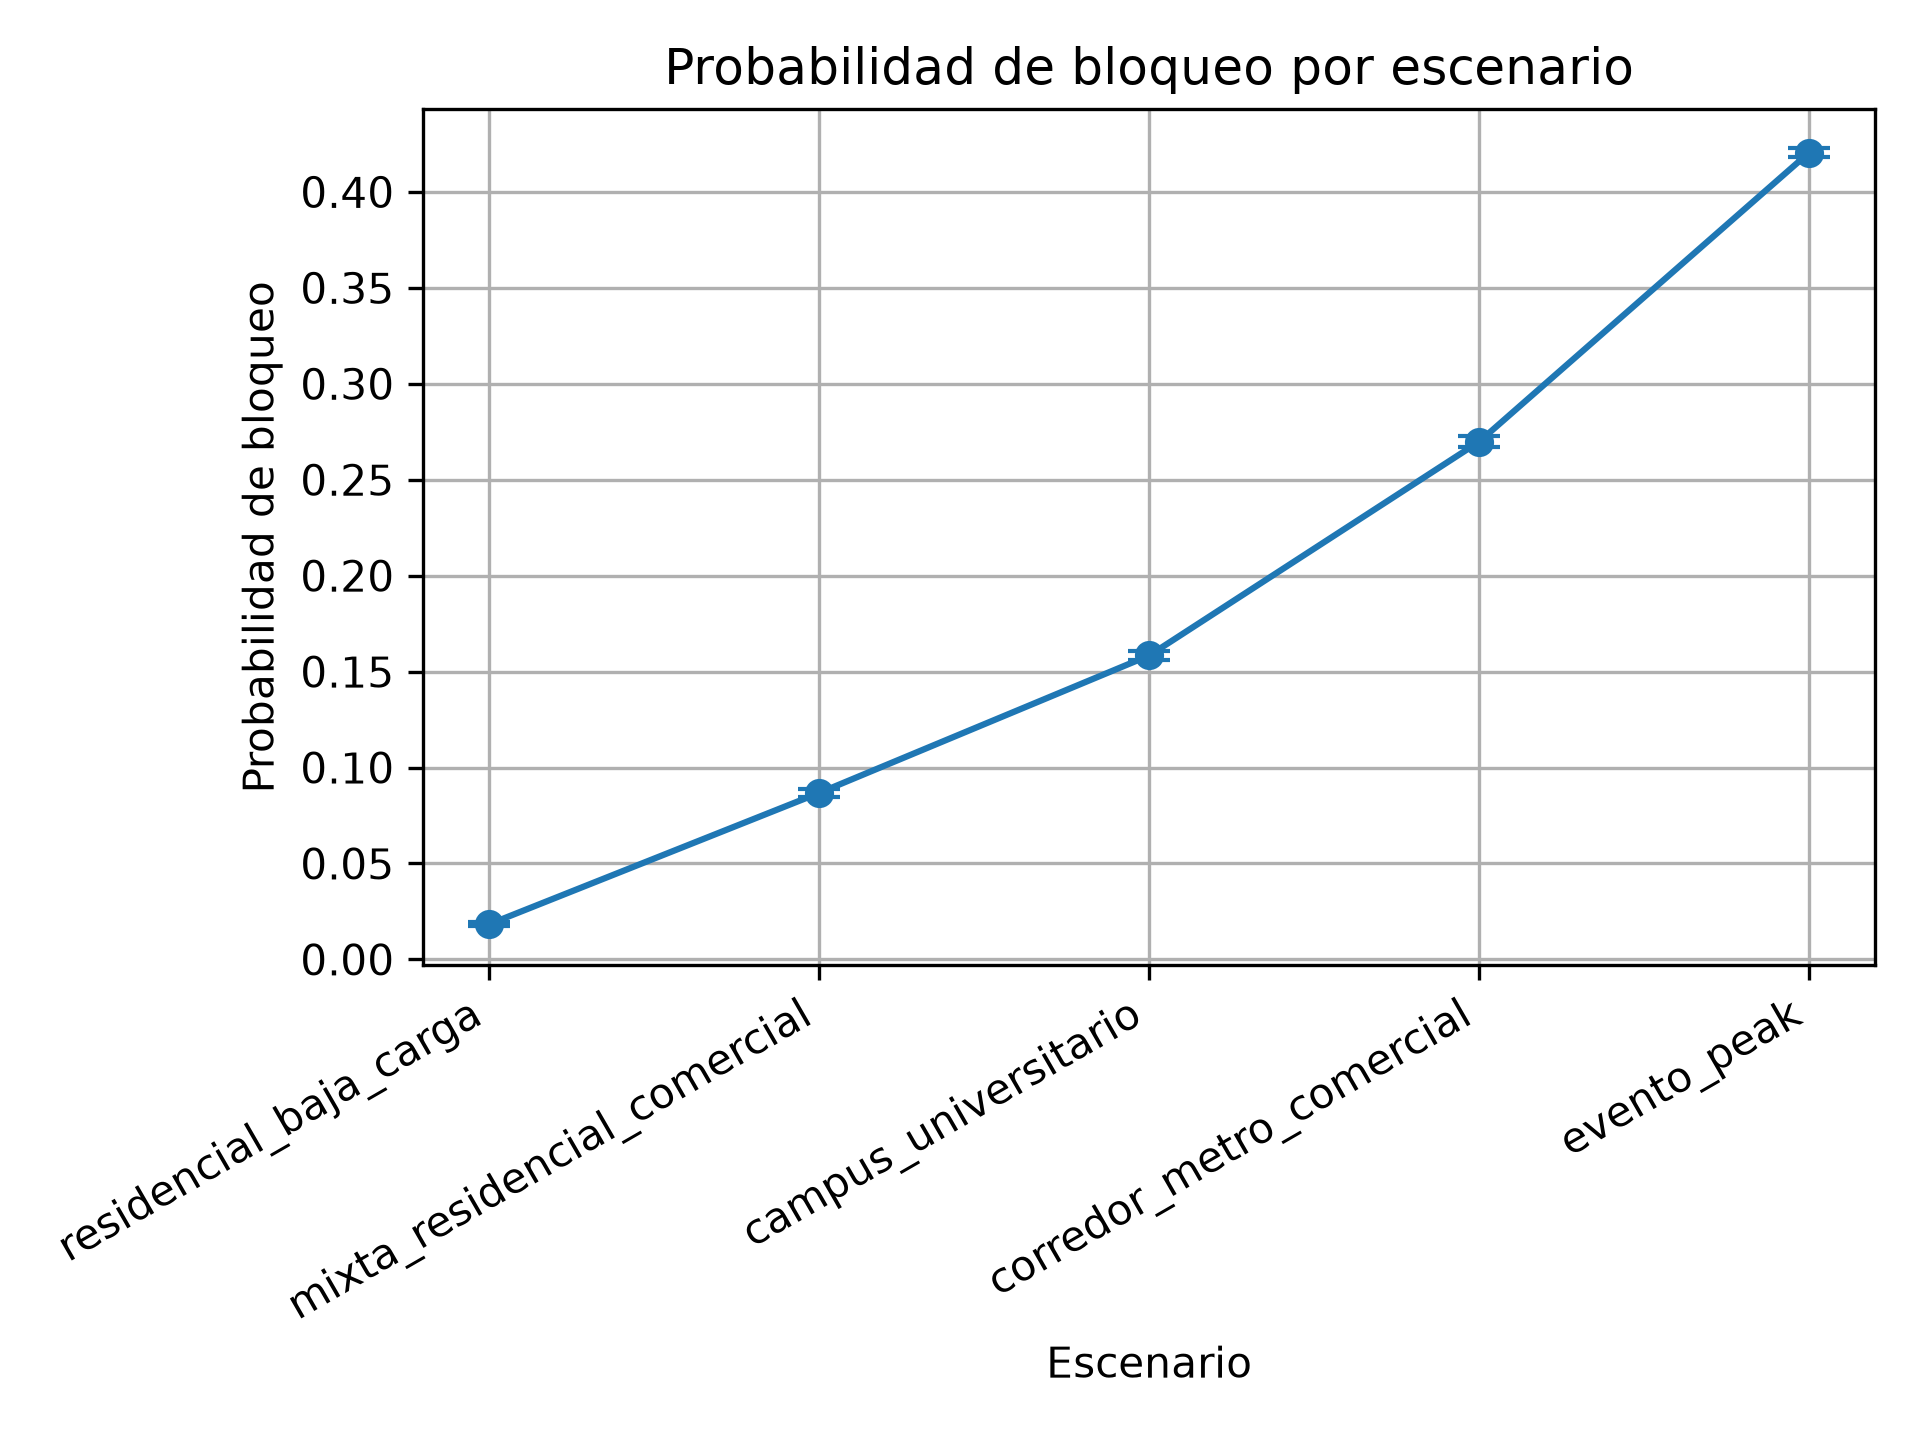

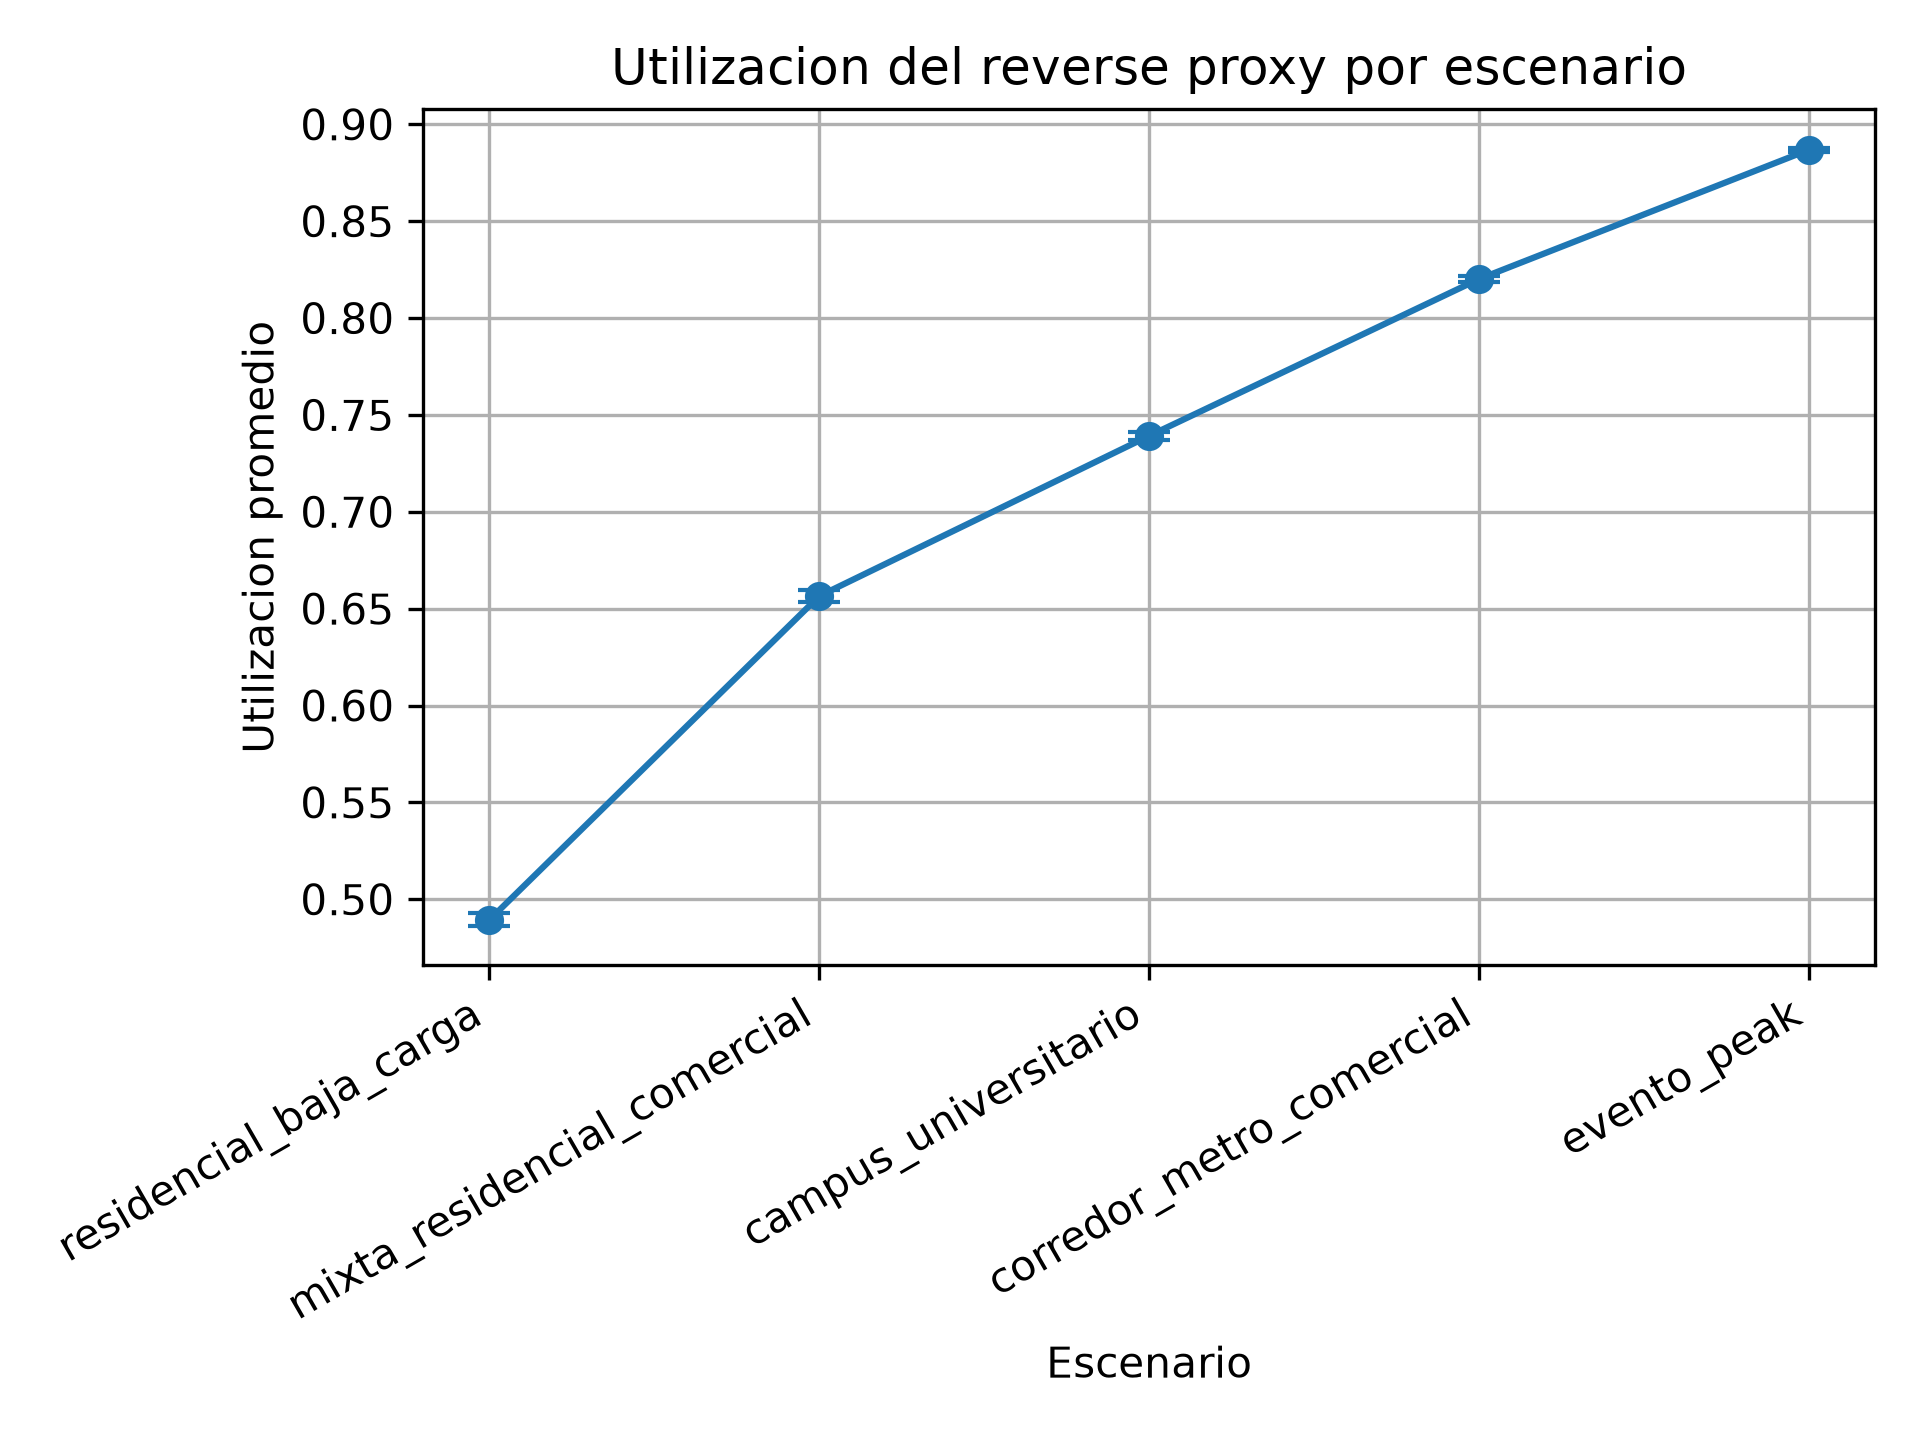

In [16]:
display(Image(filename=str(RESULTS / "scenario_blocking_probability.png")))
display(Image(filename=str(RESULTS / "scenario_utilization.png")))

## 5. Barrido de capacidad del reverse proxy
Luego de observar que algunos escenarios generan una probabilidad de bloqueo alta, se realizó un segundo experimento variando la capacidad máxima del reverse proxy.

Para este análisis se mantuvo fija una carga exigente, similar al escenario `corredor_metro_comercial`, con tasa de llegada λ = 11.25 y tasa de servicio μ = 1.0. A partir de eso, se evaluaron distintas capacidades para observar cómo cambia la probabilidad de bloqueo cuando el proxy puede atender más solicitudes simultáneamente.

Este experimento permite responder una pregunta relevante para el proyecto:

> ¿Qué capacidad debería tener el reverse proxy para mantener la tasa de rechazo bajo un umbral razonable?

In [17]:
capacity_df = pd.read_csv(RESULTS / "capacity_sweep_summary.csv")

capacity_table = capacity_df[
    [
        "capacity",
        "arrival_rate",
        "service_rate",
        "blocking_probability_mean",
        "utilization_mean",
        "mean_rejected",
        "mean_accepted",
        "mean_arrivals",
    ]
].copy()

capacity_table["blocking_probability_mean_%"] = 100 * capacity_table["blocking_probability_mean"]
capacity_table["utilization_mean_%"] = 100 * capacity_table["utilization_mean"]

capacity_table[
    [
        "capacity",
        "arrival_rate",
        "blocking_probability_mean_%",
        "utilization_mean_%",
        "mean_rejected",
        "mean_accepted",
        "mean_arrivals",
    ]
]

,capacity,arrival_rate,blocking_probability_mean_%,utilization_mean_%,mean_rejected,mean_accepted,mean_arrivals
0,6,11.25,52.827476,87.719468,5937.233333,5301.133333,11238.366667
1,8,11.25,39.023623,85.167501,4383.800000,6849.466667,11233.266667
2,10,11.25,26.832322,81.870536,3012.000000,8212.133333,11224.133333
3,12,11.25,16.795623,77.805348,1888.733333,9353.700000,11242.433333
4,14,11.25,9.262024,72.868280,1042.333333,10207.400000,11249.733333
5,16,11.25,4.368468,67.149243,492.000000,10762.433333,11254.433333
6,20,11.25,0.577343,55.817596,65.033333,11191.700000,11256.733333
7,24,11.25,0.025740,46.696361,2.900000,11236.700000,11239.600000
8,30,11.25,0.000000,37.510535,0.000000,11257.166667,11257.166667


### Interpretación del barrido de capacidad

La tabla muestra cómo cambia la probabilidad de bloqueo cuando se aumenta la capacidad máxima del reverse proxy, manteniendo fija la tasa de llegada en λ = 11.25 y la tasa de servicio en μ = 1.0.

El resultado más evidente es que la probabilidad de bloqueo disminuye a medida que aumenta la capacidad del sistema. Con capacidades bajas, como 6 u 8 solicitudes simultáneas, el proxy se encuentra muy saturado, rechazando una parte importante de las solicitudes. En particular, con capacidad 6 el bloqueo promedio supera el 52%, mientras que con capacidad 8 sigue siendo cercano al 39%.

Con capacidad 10, que fue la capacidad usada inicialmente para comparar los escenarios de carga, el bloqueo promedio es cercano al 26.83%. Esto confirma que esa configuración no es suficiente para una carga exigente como la asociada al escenario `corredor_metro_comercial`.

Al aumentar la capacidad a 12 y 14, la probabilidad de bloqueo baja de forma importante, aunque todavía se mantiene sobre un nivel que podría considerarse alto. El cambio más relevante aparece con capacidad 16, donde el bloqueo promedio llega aproximadamente a 4.37%, quedando bajo el umbral de 5%.

Por lo tanto, dentro de las capacidades evaluadas, **c = 16** es la primera configuración que permite mantener la probabilidad de bloqueo bajo 5%. Este resultado entrega una referencia concreta para dimensionar el reverse proxy bajo una carga exigente.

También se observa que al seguir aumentando la capacidad, por ejemplo a 20, 24 o 30, la probabilidad de bloqueo se vuelve casi nula. Sin embargo, en esos casos la utilización promedio baja, lo que puede interpretarse como una posible sobredimensión del sistema para esta carga.


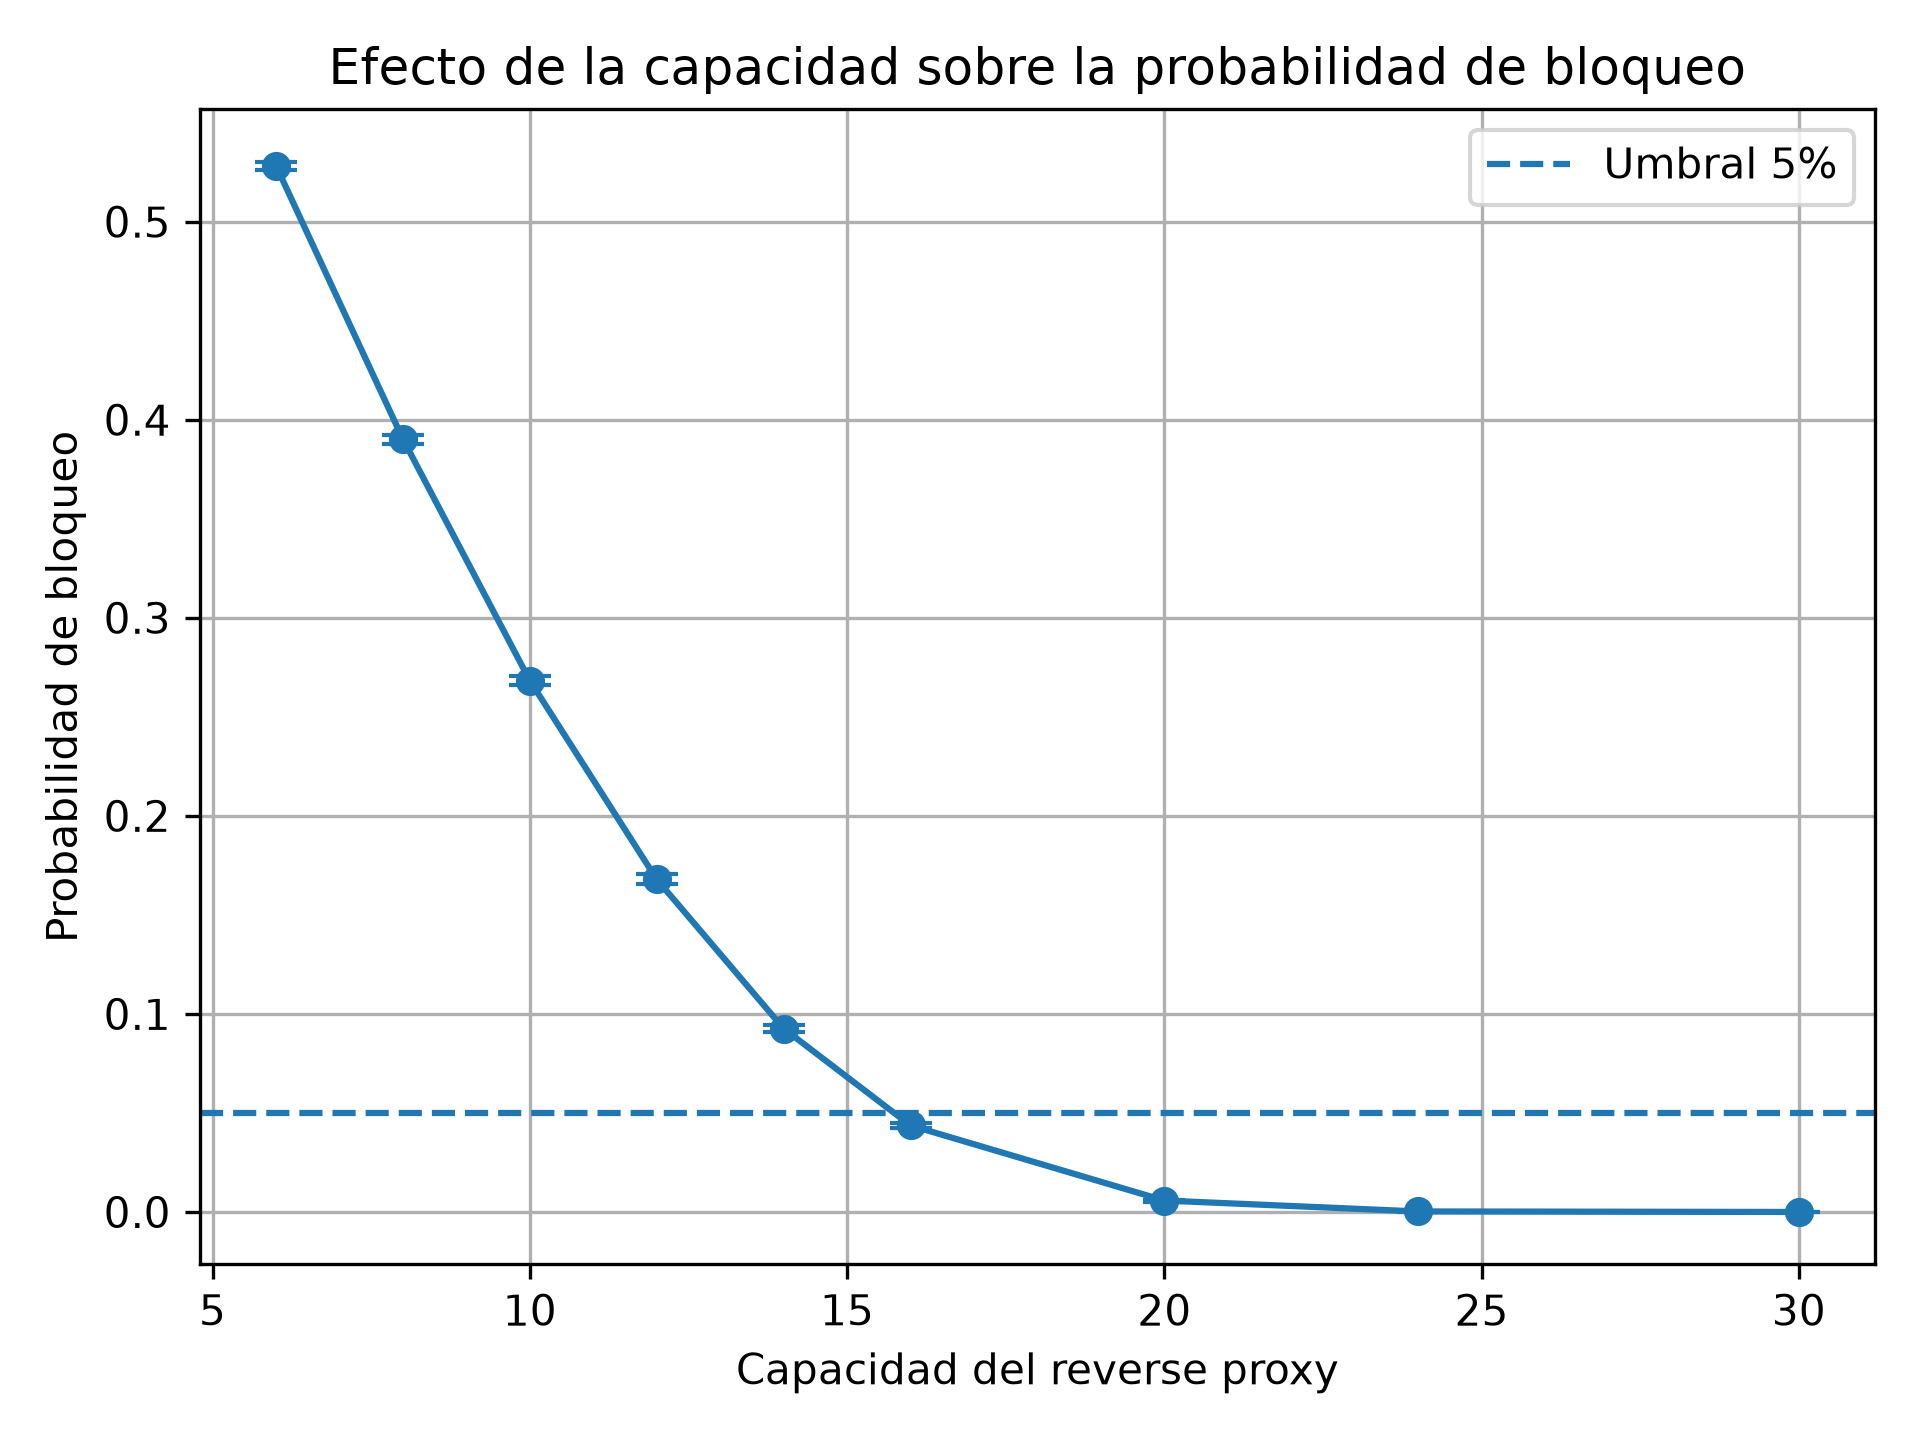

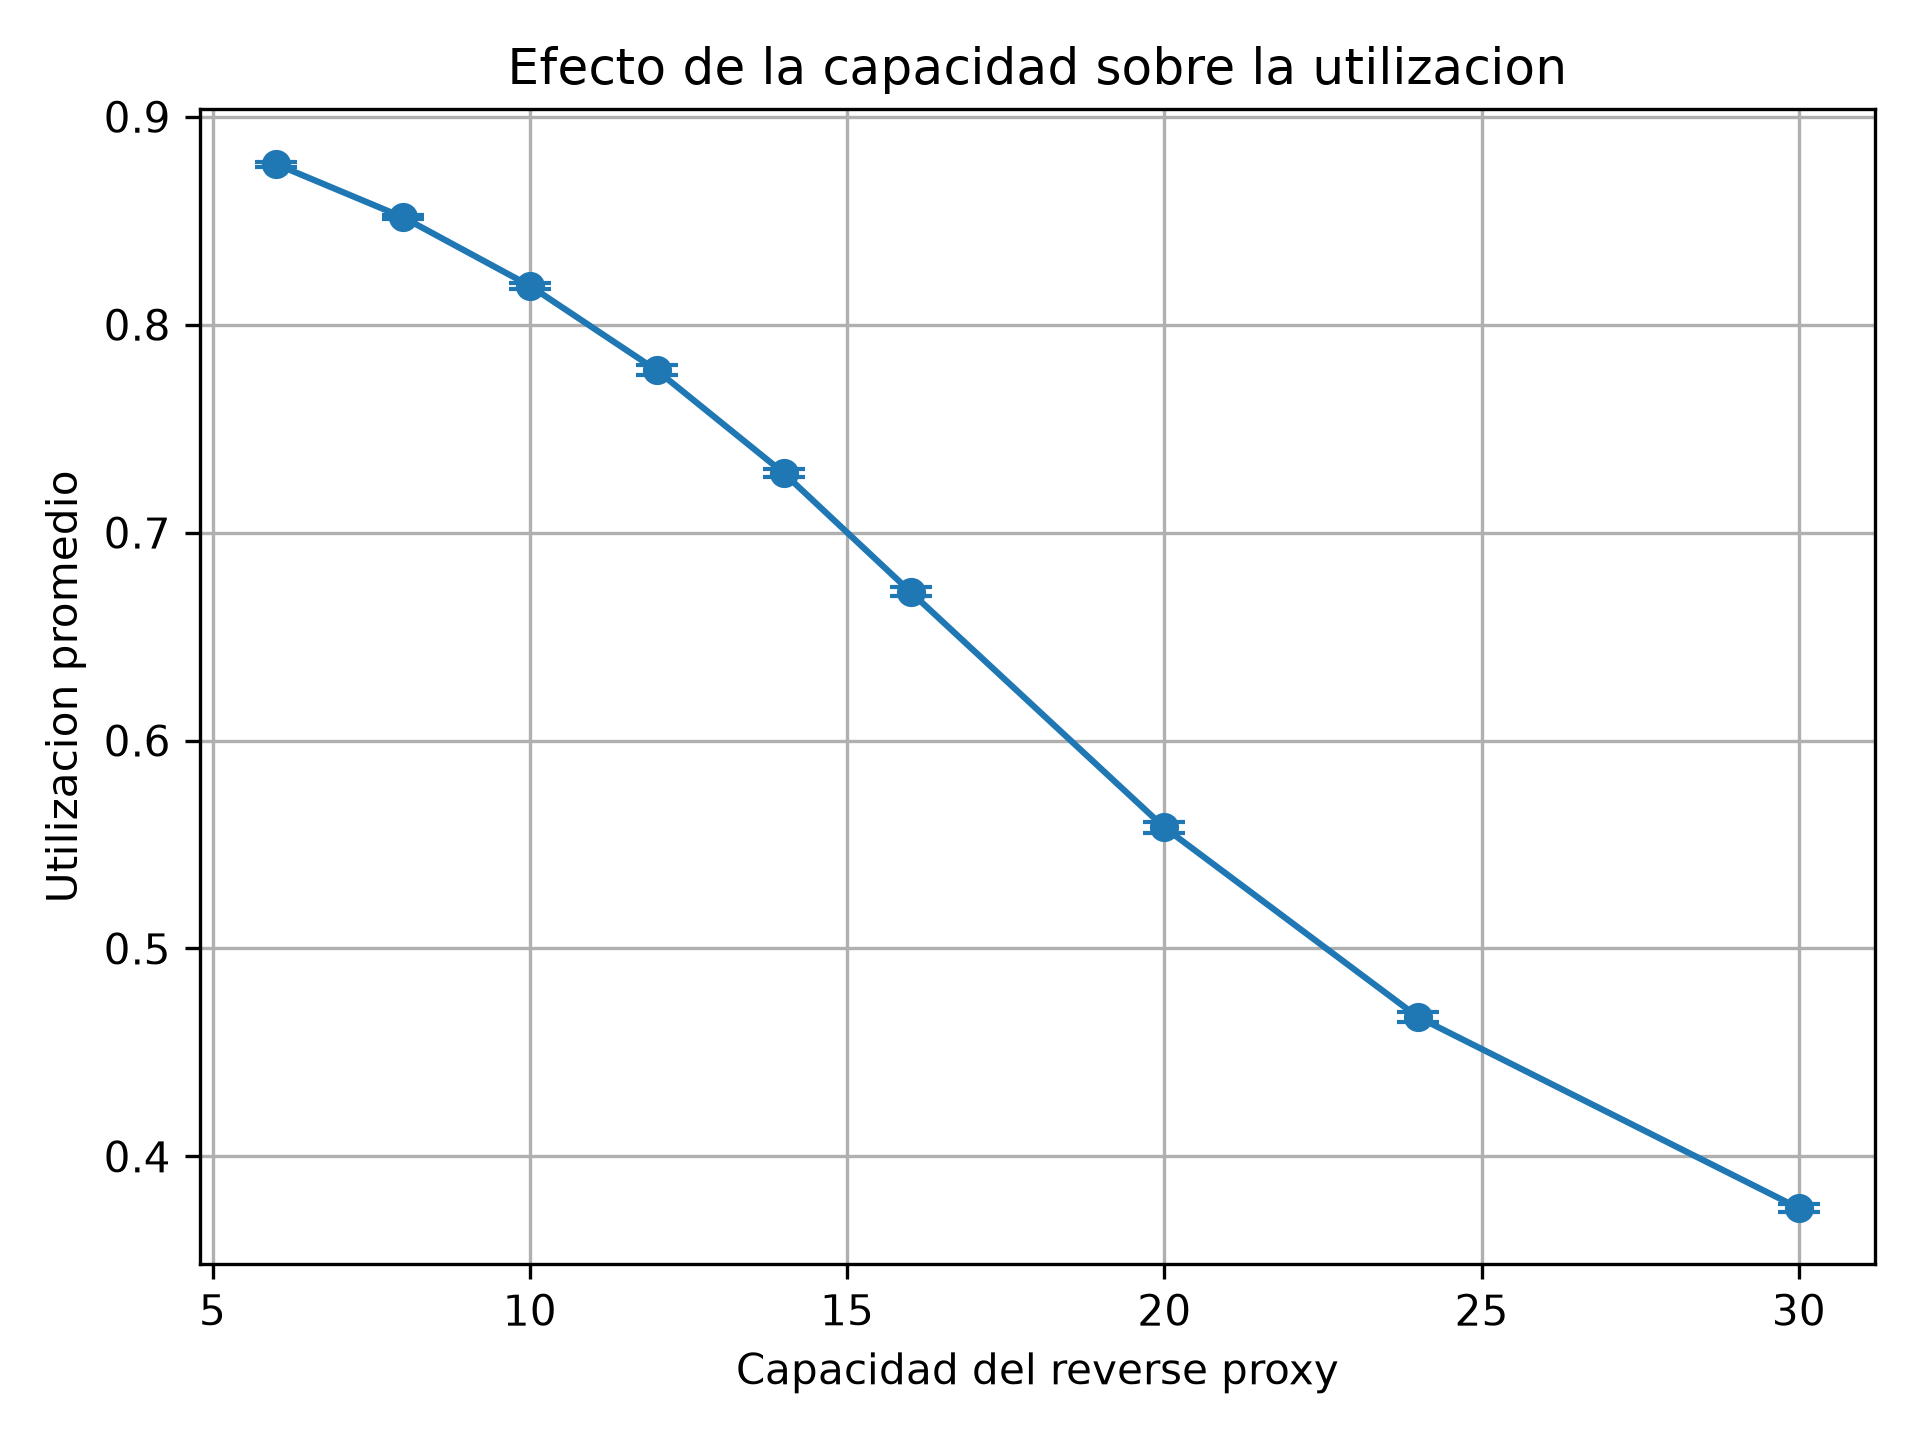

In [18]:
display(Image(filename=str(RESULTS / "capacity_sweep_blocking_probability.png")))
display(Image(filename=str(RESULTS / "capacity_sweep_utilization.png")))

In [19]:
target = 0.05

feasible = capacity_df[capacity_df["blocking_probability_mean"] <= target]

if len(feasible) > 0:
    min_capacity = int(feasible.iloc[0]["capacity"])
    blocking = feasible.iloc[0]["blocking_probability_mean"]
    
    print(f"Capacidad mínima evaluada bajo {target:.0%} de bloqueo: c = {min_capacity}")
    print(f"Bloqueo promedio para c = {min_capacity}: {blocking:.4f} ({100 * blocking:.2f}%)")
else:
    print(f"Ninguna capacidad evaluada logró quedar bajo {target:.0%} de bloqueo.")

Capacidad mínima evaluada bajo 5% de bloqueo: c = 16
Bloqueo promedio para c = 16: 0.0437 (4.37%)


## 6. Evolución de la probabilidad de bloqueo durante la simulación

Además de observar la probabilidad de bloqueo final, se generó una traza para estudiar cómo evoluciona esta métrica mientras avanza la simulación. Para esto se utilizó una carga exigente con tasa de llegada λ = 11.25, tasa de servicio μ = 1.0 y capacidad del reverse proxy igual a 10 solicitudes simultáneas.

El gráfico muestra la probabilidad de bloqueo acumulada a medida que aumenta la cantidad de solicitudes generadas. Al inicio de la simulación se observan fluctuaciones más marcadas, lo cual es esperable porque todavía hay pocas solicitudes procesadas y cada rechazo tiene un efecto mayor sobre la proporción acumulada.

A medida que avanza la simulación, la curva comienza a estabilizarse alrededor de un valor cercano a 0.27. Este resultado es consistente con lo observado en el escenario `corredor_metro_comercial`, donde la probabilidad de bloqueo promedio fue aproximadamente 26.98%.

Esta evolución permite visualizar que la métrica de bloqueo no surge de un evento puntual, sino que se va estabilizando conforme aumenta el número de solicitudes procesadas. Por esto, el gráfico sirve como apoyo para la verificación del comportamiento del simulador y para justificar el uso de un horizonte de simulación fijo.


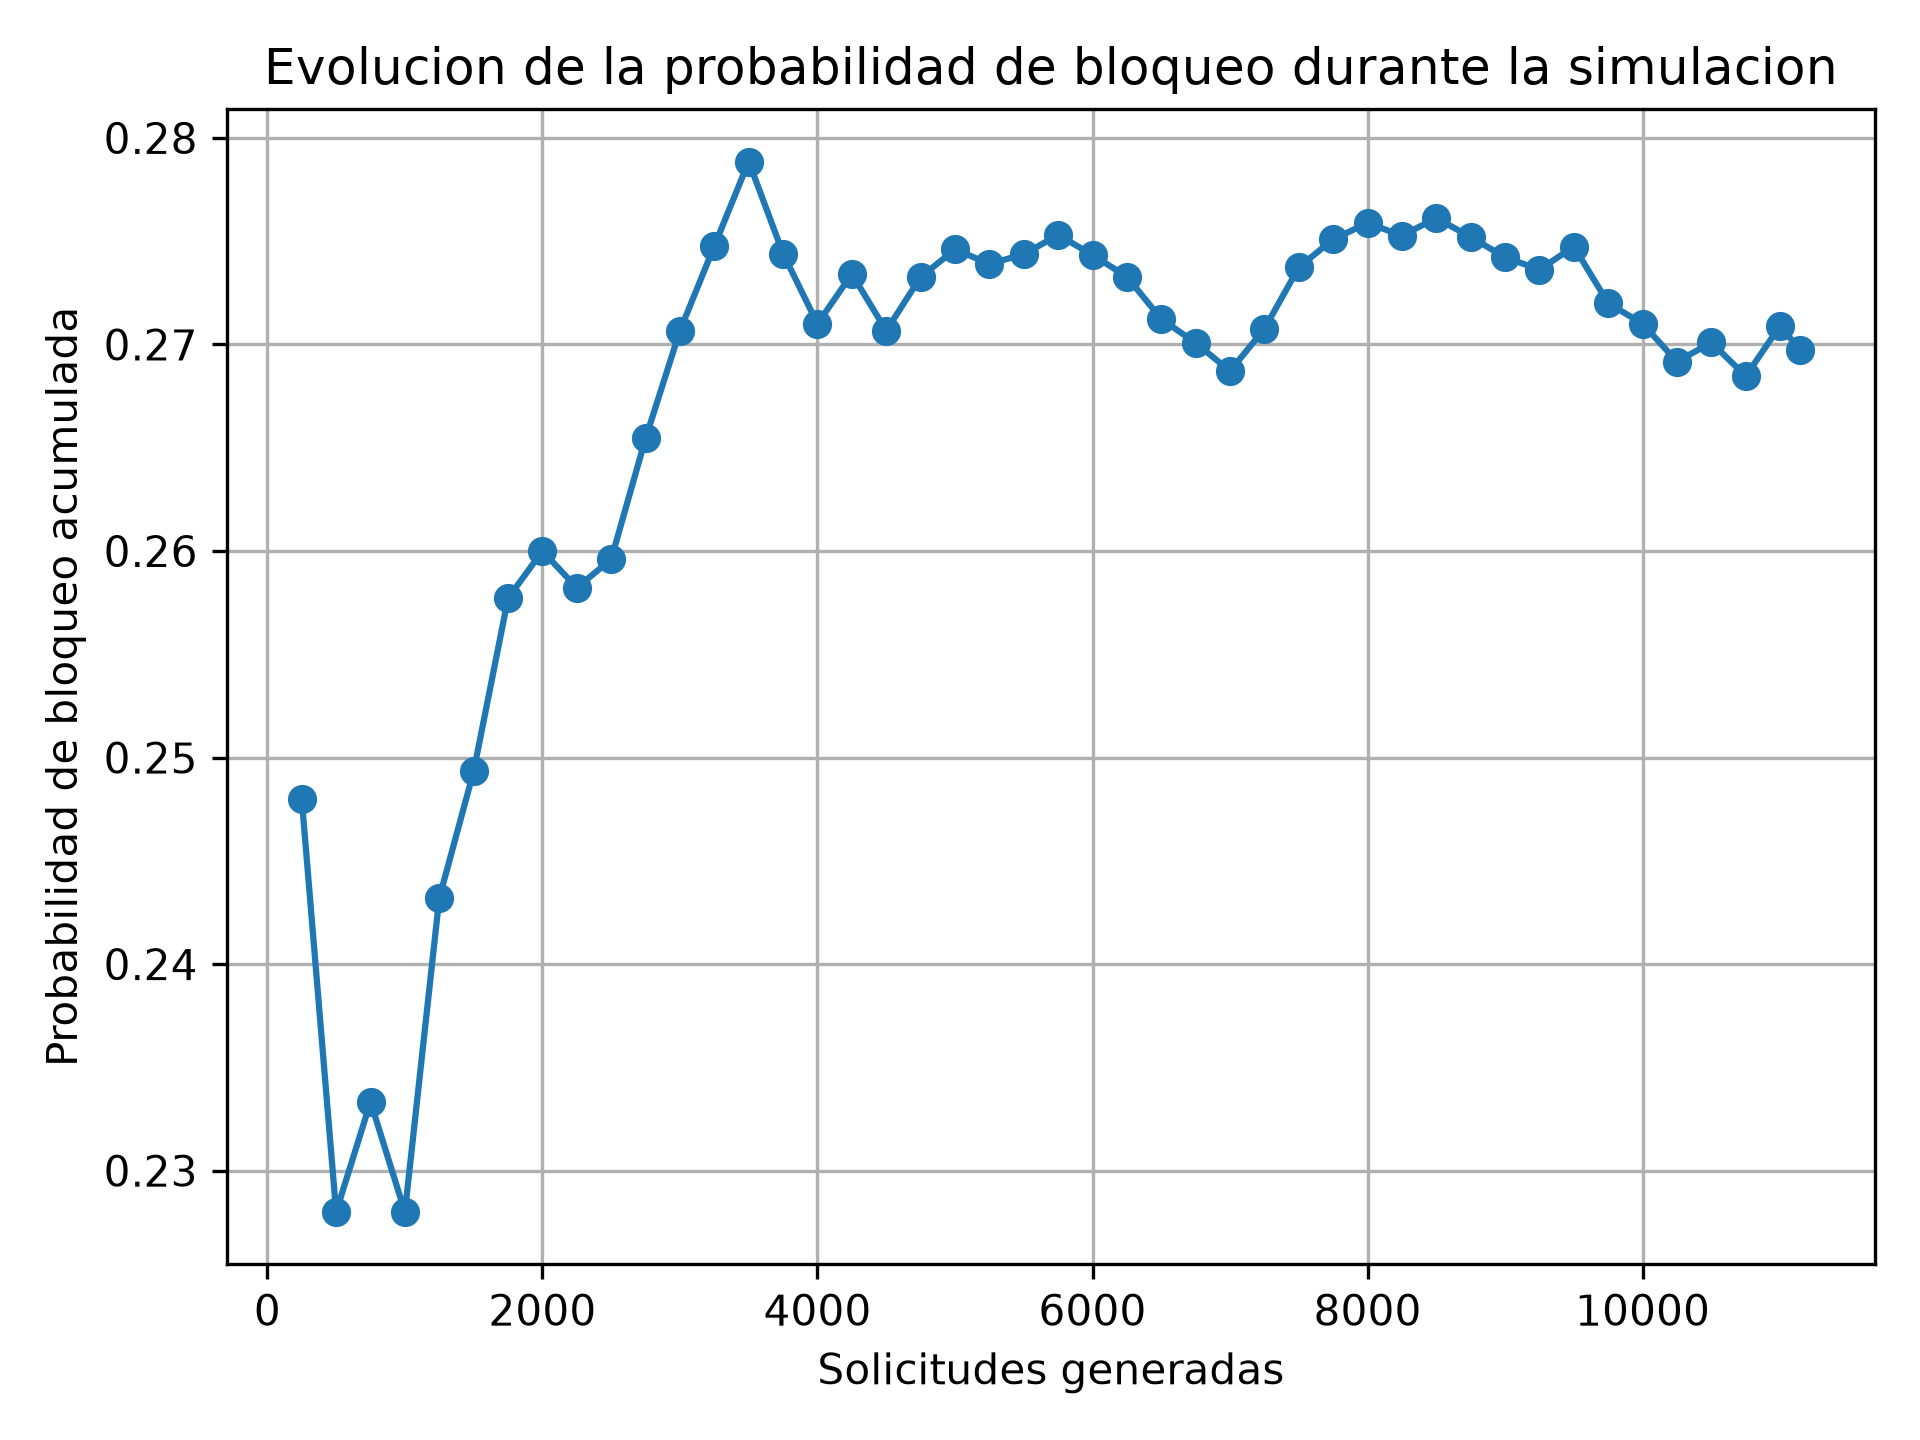


Evolucion de probabilidad de bloqueo

arrival_rate = 11.25
service_rate = 1.0
capacity = 10
simulation_time = 1000
seed = 2026

bloqueo_final = 0.2697173620457604

Archivos generados:
C:\Users\edopa\OneDrive\Desktop\rproxy-sim\results\blocking_trace.csv
C:\Users\edopa\OneDrive\Desktop\rproxy-sim\results\blocking_trace_plot.png



In [24]:
display(Image(filename=str(RESULTS / "blocking_trace_plot.png")))
print((RESULTS / "blocking_trace_summary.txt").read_text(encoding="utf-8"))

## 6. Conclusiones preliminares

A partir de los experimentos realizados se obtienen tres resultados principales.

Primero, el simulador base fue validado correctamente al compararlo con Erlang B. La probabilidad de bloqueo simulada fue muy cercana al valor teórico, lo que entrega confianza en que el núcleo DES está funcionando correctamente para el caso M/M/c/c.

Segundo, la comparación de escenarios muestra que el reverse proxy responde bien en condiciones de baja carga, pero comienza a saturarse cuando aumenta la concentración de solicitudes. En particular, los escenarios `corredor_metro_comercial` y `evento_peak` presentan tasas de bloqueo altas cuando la capacidad se mantiene fija en 10 solicitudes simultáneas.

Tercero, el barrido de capacidad muestra que aumentar la capacidad del proxy reduce de forma importante la probabilidad de bloqueo. Para una carga de λ = 11.25, la menor capacidad evaluada que logra mantener el bloqueo bajo 5% fue c = 16.

Estos resultados dejan una base sólida para el informe, ya que permiten conectar el modelo de simulación, la validación, los experimentos y una primera recomendación de dimensionamiento del reverse proxy.